# Intraday Data Sanity Check

Loads cached 5-minute futures data from `cache/intraday_5m_60d.pkl` and checks:
- ticker coverage and session counts
- distribution across trade dates and intraday periods
- detailed plots for two sample trade dates


In [13]:
from pathlib import Path
import datetime as dt
import pickle

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 140)

BASE_DIR = Path.cwd()
if BASE_DIR.name != 'intraday_vol_volume':
    candidate = BASE_DIR / '21_Backtest' / 'draft_obs' / 'intraday_vol_volume'
    if candidate.exists():
        BASE_DIR = candidate

CACHE_PATH = BASE_DIR / 'cache' / 'intraday_5m_60d.pkl'
SESSION_START = dt.time(18, 0)

print('Base dir :', BASE_DIR)
print('Cache    :', CACHE_PATH)
print('Exists   :', CACHE_PATH.exists())

def add_cash_session_lines(ax, trade_date):
    session_930 = pd.Timestamp.combine(pd.Timestamp(trade_date).date(), dt.time(9, 30)).tz_localize('US/Eastern')
    session_1600 = pd.Timestamp.combine(pd.Timestamp(trade_date).date(), dt.time(16, 0)).tz_localize('US/Eastern')
    ax.axvline(session_930, color='black', linewidth=1.0)
    ax.axvline(session_1600, color='black', linewidth=1.0)


Base dir : c:\Users\qingy\OneDrive\Documents\Obsidian Vault\21_Backtest\draft_obs\intraday_vol_volume
Cache    : c:\Users\qingy\OneDrive\Documents\Obsidian Vault\21_Backtest\draft_obs\intraday_vol_volume\cache\intraday_5m_60d.pkl
Exists   : True


In [14]:
with open(CACHE_PATH, 'rb') as f:
    raw_cache = pickle.load(f)

print('Tickers in cache:', list(raw_cache.keys()))
assert raw_cache, 'Cache is empty.'

Tickers in cache: ['ES=F']


In [15]:
def assign_trade_date(index: pd.DatetimeIndex) -> pd.Index:
    return pd.Index([
        (ts + pd.Timedelta(days=1)).date() if ts.time() >= SESSION_START else ts.date()
        for ts in index
    ])


def prepare_ticker_frame(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy().sort_index()
    out.columns = [str(c).lower() for c in out.columns]
    out['bar_ret'] = out['close'].pct_change().fillna(0.0)
    out['abs_bar_ret'] = out['bar_ret'].abs()
    out['log_volume'] = np.log(out['volume'].clip(lower=1.0))
    out['trade_date'] = assign_trade_date(out.index)
    out['hhmm'] = out.index.hour * 100 + out.index.minute
    out['weekday'] = pd.Index(out['trade_date']).map(lambda d: pd.Timestamp(d).day_name())
    out['month'] = pd.Index(out['trade_date']).map(lambda d: pd.Timestamp(d).strftime('%Y-%m'))
    out['bar_idx'] = out.groupby('trade_date').cumcount()
    return out


prepared = {ticker: prepare_ticker_frame(df) for ticker, df in raw_cache.items()}
ticker = next(iter(prepared))
df = prepared[ticker]
print('Default ticker:', ticker)
df.head()

Default ticker: ES=F


,open,high,low,close,volume,bar_ret,abs_bar_ret,log_volume,trade_date,hhmm,weekday,month,bar_idx
2026-01-26 00:00:00-05:00,6926.75,6927.75,6926.25,6927.00,0.0,0.000000,0.000000,0.000000,2026-01-26,0,Monday,2026-01,0
2026-01-26 00:05:00-05:00,6927.00,6927.50,6925.75,6926.25,254.0,-0.000108,0.000108,5.537334,2026-01-26,5,Monday,2026-01,1
2026-01-26 00:10:00-05:00,6926.00,6927.00,6925.50,6925.75,241.0,-0.000072,0.000072,5.484797,2026-01-26,10,Monday,2026-01,2
2026-01-26 00:15:00-05:00,6925.75,6929.00,6925.75,6928.75,383.0,0.000433,0.000433,5.948035,2026-01-26,15,Monday,2026-01,3
2026-01-26 00:20:00-05:00,6928.75,6930.00,6928.00,6928.50,365.0,-0.000036,0.000036,5.899897,2026-01-26,20,Monday,2026-01,4


## Cache Coverage

In [16]:
coverage_rows = []
for ticker_name, ticker_df in prepared.items():
    session_counts = ticker_df.groupby('trade_date').size()
    coverage_rows.append({
        'ticker': ticker_name,
        'n_rows': len(ticker_df),
        'n_trade_dates': ticker_df['trade_date'].nunique(),
        'start_ts': ticker_df.index.min(),
        'end_ts': ticker_df.index.max(),
        'min_bars_per_date': int(session_counts.min()),
        'median_bars_per_date': float(session_counts.median()),
        'max_bars_per_date': int(session_counts.max()),
        'zero_volume_share': float((ticker_df['volume'] == 0).mean()),
    })

coverage = pd.DataFrame(coverage_rows)
coverage

,ticker,n_rows,n_trade_dates,start_ts,end_ts,min_bars_per_date,median_bars_per_date,max_bars_per_date,zero_volume_share
0,ES=F,13952,52,2026-01-26 00:00:00-05:00,2026-04-07 16:55:00-04:00,38,276.0,276,0.042216


## Distribution Over Periods

,count,mean,std,min,25%,50%,75%,max
bars_per_trade_date,52.0,268.307692,35.459747,38.0,276.0,276.0,276.0,276.0


,obs
weekday,
Monday,2709.0
Tuesday,2963.0
Wednesday,2760.0
Thursday,2760.0
Friday,2760.0
Saturday,0.0
Sunday,0.0


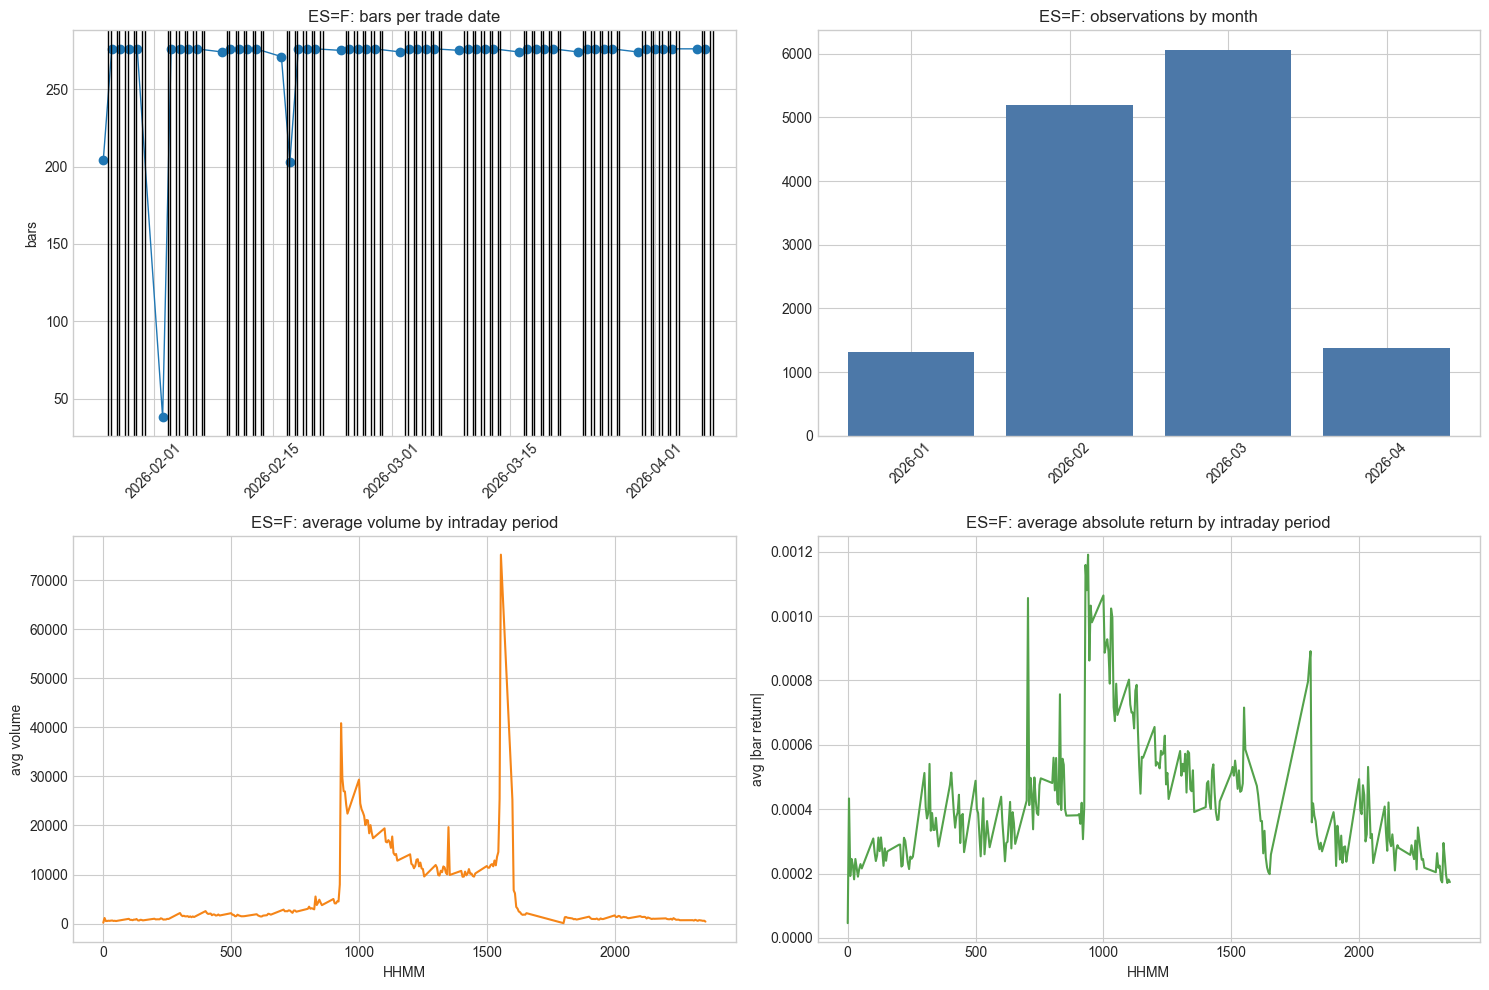

In [17]:
session_counts = df.groupby('trade_date').size()
intraday_profile = df.groupby('hhmm').agg(
    bars=('close', 'size'),
    avg_volume=('volume', 'mean'),
    avg_abs_bar_ret=('abs_bar_ret', 'mean'),
)
monthly_counts = df.groupby('month').size()
weekday_counts = df.groupby('weekday').size().reindex(
    ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
).fillna(0)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes[0, 0].plot(session_counts.index, session_counts.values, marker='o', linewidth=1)
axes[0, 0].set_title(f'{ticker}: bars per trade date')
axes[0, 0].set_ylabel('bars')
axes[0, 0].tick_params(axis='x', rotation=45)
for trade_date in session_counts.index:
    add_cash_session_lines(axes[0, 0], trade_date)

axes[0, 1].bar(monthly_counts.index, monthly_counts.values, color='#4C78A8')
axes[0, 1].set_title(f'{ticker}: observations by month')
axes[0, 1].tick_params(axis='x', rotation=45)

axes[1, 0].plot(intraday_profile.index, intraday_profile['avg_volume'], color='#F58518')
axes[1, 0].set_title(f'{ticker}: average volume by intraday period')
axes[1, 0].set_xlabel('HHMM')
axes[1, 0].set_ylabel('avg volume')

axes[1, 1].plot(intraday_profile.index, intraday_profile['avg_abs_bar_ret'], color='#54A24B')
axes[1, 1].set_title(f'{ticker}: average absolute return by intraday period')
axes[1, 1].set_xlabel('HHMM')
axes[1, 1].set_ylabel('avg |bar return|')

plt.tight_layout()

display(session_counts.describe().to_frame('bars_per_trade_date').T)
display(weekday_counts.to_frame('obs'))

## Two Sample Dates

In [18]:
available_dates = sorted(df['trade_date'].unique())
sample_dates = [available_dates[1], available_dates[len(available_dates) // 2]] if len(available_dates) > 2 else available_dates[:2]
sample_dates

[datetime.date(2026, 1, 27), datetime.date(2026, 3, 3)]

,count,mean,std,min,25%,50%,75%,max
open,276.0,7000.161232,9.816419,6972.75,6996.5000,6999.25,7007.3125,7017.50
high,276.0,7001.369565,9.788826,6977.25,6997.7500,7000.50,7009.3750,7018.50
low,276.0,6999.120471,9.674673,6972.00,6995.5000,6998.50,7006.5000,7016.50
close,276.0,7000.283514,9.738980,6972.75,6996.6875,6999.25,7007.6875,7017.75
volume,276.0,3343.510870,6340.719041,0.00,465.7500,900.00,4164.5000,74936.00


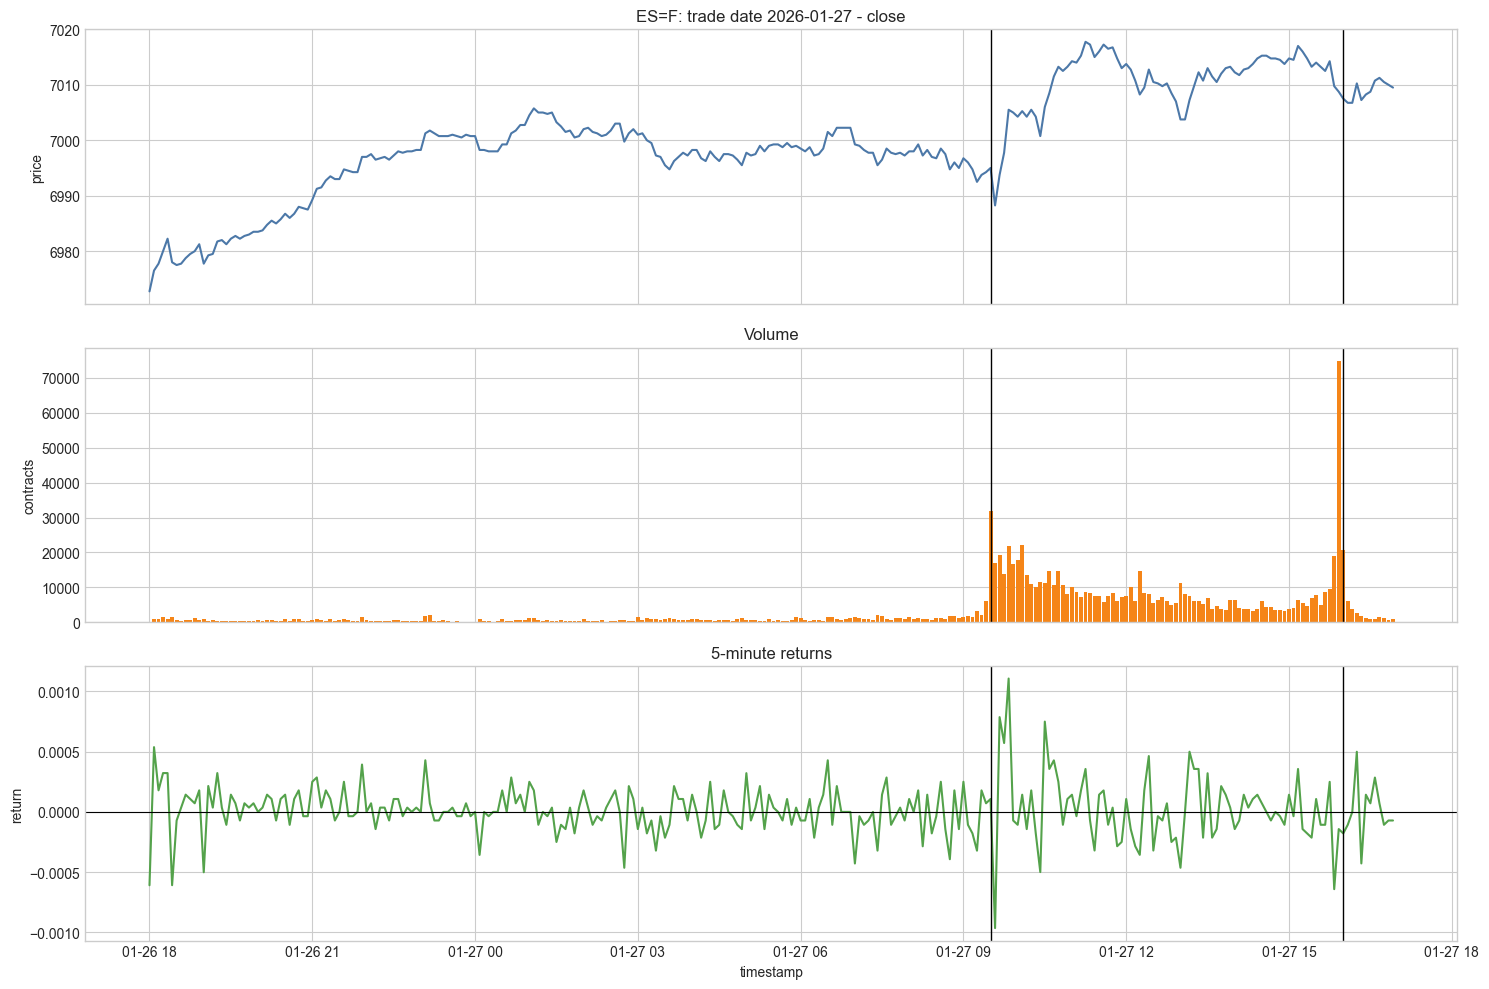

,count,mean,std,min,25%,50%,75%,max
open,276.0,6813.268116,38.366903,6720.75,6783.1875,6819.250,6841.0625,6883.50
high,276.0,6817.201087,36.607617,6728.50,6787.4375,6821.625,6843.8750,6886.00
low,276.0,6808.996377,39.459720,6718.75,6777.3750,6814.750,6837.6250,6879.25
close,276.0,6812.987319,38.087368,6720.75,6782.9375,6818.000,6840.5000,6883.00
volume,276.0,7941.858696,10364.060933,0.00,1353.2500,3801.000,10629.5000,70160.00


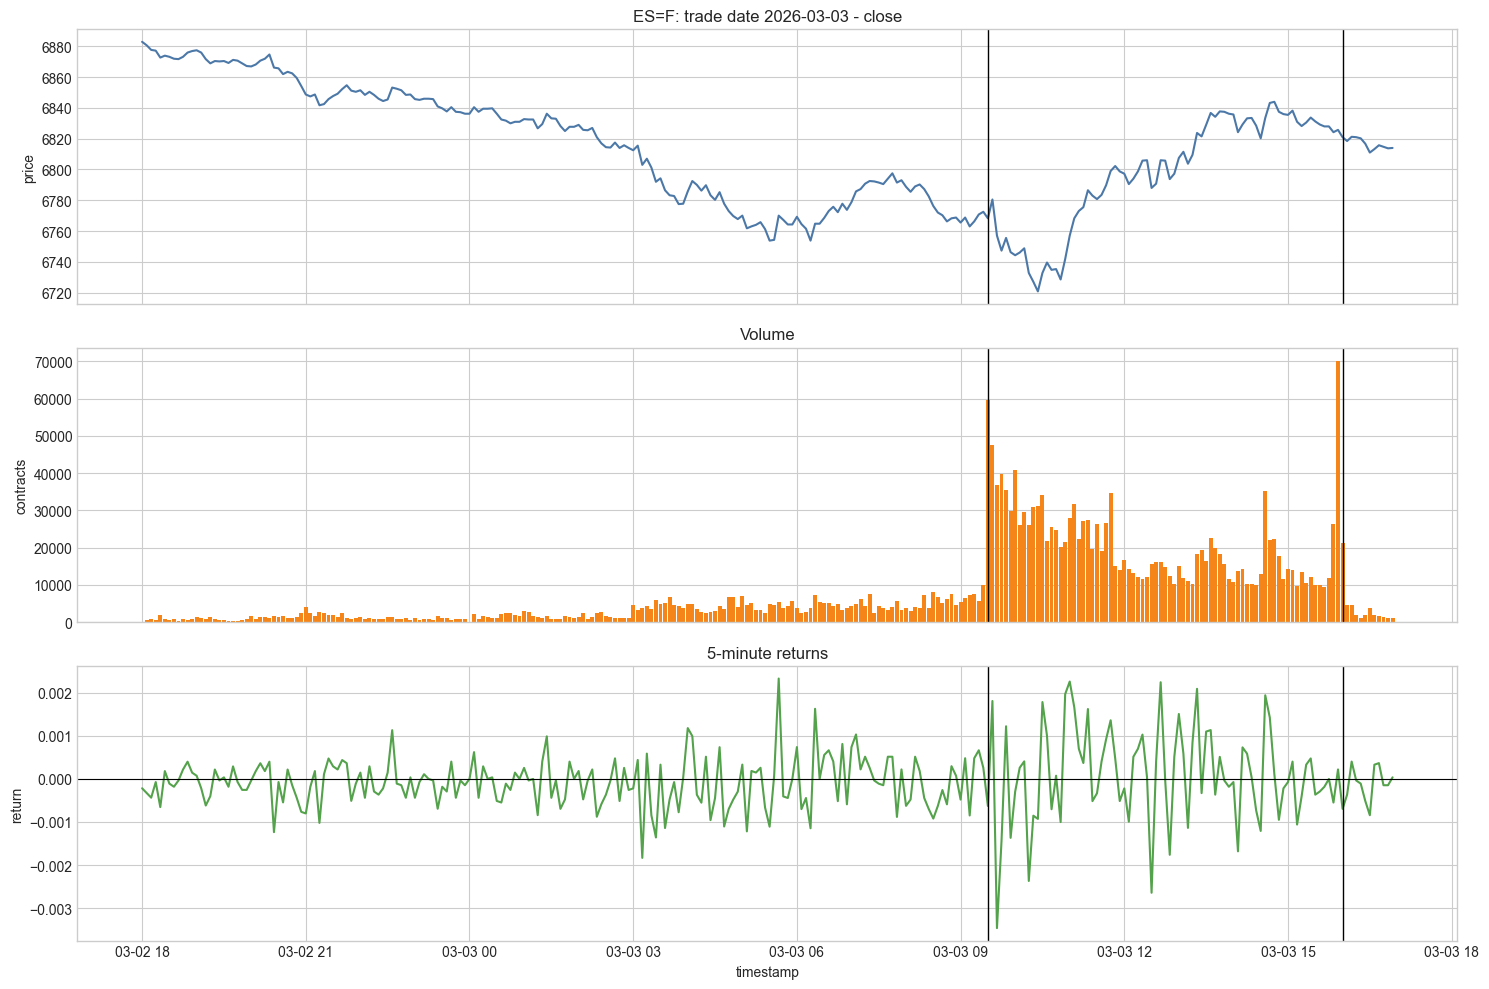

In [19]:
for sample_date in sample_dates:
    day = df[df['trade_date'] == sample_date].copy()
    display(day[['open', 'high', 'low', 'close', 'volume']].describe().T)

    fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)
    axes[0].plot(day.index, day['close'], color='#4C78A8')
    axes[0].set_title(f'{ticker}: trade date {sample_date} - close')
    axes[0].set_ylabel('price')

    axes[1].bar(day.index, day['volume'], width=0.003, color='#F58518')
    axes[1].set_title('Volume')
    axes[1].set_ylabel('contracts')

    axes[2].plot(day.index, day['bar_ret'], color='#54A24B')
    axes[2].axhline(0.0, color='black', linewidth=0.8)
    axes[2].set_title('5-minute returns')
    axes[2].set_ylabel('return')
    axes[2].set_xlabel('timestamp')

    for ax in axes:
        add_cash_session_lines(ax, sample_date)

    plt.tight_layout()
    plt.show()